# JAX vs PyTorch: Fine-Tuning Qwen2.5-1.5B on GPU and TPU

Benchmarking full fine-tuning throughput and memory footprint across three training setups —
**PyTorch DDP**, **PyTorch FSDP**, and **JAX (FSDP-style sharding)** — on two very different
accelerators: **2x NVIDIA T4** and **Cloud TPU v6e-4**.

Same model (`Qwen/Qwen2.5-1.5B-Instruct`), same dataset (Alpaca), same sequence length —
only the framework and hardware change.

# Theme

In [32]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

COLORS = {
    "bg": "#EAECF0",
    "black": "#000000",
    "navy": "#233D4D",
    "orange": "#FE7F2D",
}

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
mpl.rcParams["figure.facecolor"] = COLORS["bg"]
mpl.rcParams["axes.facecolor"] = COLORS["bg"]
mpl.rcParams["axes.edgecolor"] = COLORS["black"]
mpl.rcParams["text.color"] = COLORS["black"]
mpl.rcParams["axes.labelcolor"] = COLORS["black"]
mpl.rcParams["xtick.color"] = COLORS["black"]
mpl.rcParams["ytick.color"] = COLORS["black"]
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "#CCCCCC"
mpl.rcParams["grid.linewidth"] = 0.5
mpl.rcParams["figure.dpi"] = 120

FRAMEWORK_COLORS = {
    "PyTorch DDP": COLORS["black"],
    "PyTorch FSDP": COLORS["navy"],
    "JAX": COLORS["orange"],
}

In [3]:
from google.colab import drive
from google.colab import files

drive.mount('/content/drive')
uploaded = files.upload()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving JAX_Results.json to JAX_Results.json
Saving FSDP_Results.json to FSDP_Results.json


In [4]:
drive.mount('/content/drive')
uploaded = files.upload()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving results_jax_tpu.json to results_jax_tpu.json
Saving results_fsdp_tpu.json to results_fsdp_tpu.json
Saving results_ddp_tpu.json to results_ddp_tpu.json


In [9]:
import json
import os

DATA_ROOT = "results/jax_v_pytorch"

FILE_MAP = {
    ("T4_x2", "PyTorch FSDP"): "FSDP_Results.json",
    ("T4_x2", "JAX"):          "JAX_Results.json",
    ("TPU_4_cores", "PyTorch DDP"):  "results_ddp_tpu.json",
    ("TPU_4_cores", "PyTorch FSDP"): "results_fsdp_tpu.json",
    ("TPU_4_cores", "JAX"):          "results_jax_tpu.json",
}

results = {}
for (hw, fw), fname in FILE_MAP.items():
    path = os.path.join(DATA_ROOT, hw, fname)
    if not os.path.exists(path):
        print(f"MISSING: {path}")
        continue
    with open(path) as f:
        results[(hw, fw)] = json.load(f)
    print(f"loaded {hw} / {fw}: keys = {list(results[(hw, fw)].keys())}")

loaded T4_x2 / PyTorch FSDP: keys = ['framework', 'sharding_strategy', 'world_size', 'seq_len', 'per_gpu_batch_size', 'warmup_steps_excluded', 'logs']
loaded T4_x2 / JAX: keys = ['framework', 'platform', 'n_devices', 'seq_len', 'per_device_batch_size', 'global_batch_size', 'remat', 'compile_time_sec', 'logs']
loaded TPU_4_cores / PyTorch DDP: keys = ['framework', 'world_size', 'seq_len', 'per_device_batch_size', 'warmup_steps_excluded', 'logs']
loaded TPU_4_cores / PyTorch FSDP: keys = ['framework', 'world_size', 'seq_len', 'per_device_batch_size', 'warmup_steps_excluded', 'logs']
loaded TPU_4_cores / JAX: keys = ['framework', 'platform', 'n_devices', 'seq_len', 'per_device_batch_size', 'global_batch_size', 'remat', 'compile_time_sec', 'logs']


In [10]:
records = []  # one row per (hardware, framework, step)

for (hw, fw), data in results.items():
    logs = data.get("logs", data.get("log", data.get("steps", None)))
    if logs is None:
        print(f"!! no logs/log/steps key found for {hw}/{fw} -- top-level keys: {list(data.keys())}")
        continue
    print(f"{hw} / {fw}: {len(logs)} steps, first entry -> {logs[0]}")
    for entry in logs:
        row = dict(entry)
        row["hardware"] = hw
        row["framework"] = fw
        records.append(row)

print(f"\ntotal rows collected: {len(records)}")

T4_x2 / PyTorch FSDP: 90 steps, first entry -> {'step': 11, 'timestamp': 1787541345.0512397, 'step_time_sec': 3.041250464999962, 'tokens_per_sec': 336.7036065541589, 'peak_memory_mb': 8013.51904296875, 'loss': 1.7208034992218018}
T4_x2 / JAX: 99 steps, first entry -> {'step': 2, 'timestamp': 1787541019.7206728, 'step_time_sec': 45.28974179399995, 'tokens_per_sec': 22.60997655181291, 'peak_memory_mb': 10275.2666015625, 'loss': 1.3315454721450806}
TPU_4_cores / PyTorch DDP: 90 steps, first entry -> {'step': 11, 'timestamp': 1787623218.7366285, 'step_time_sec': 0.689854674000344, 'tokens_per_sec': 2968.741210556731, 'peak_memory_mb': 27491.865844726562, 'loss': 3.446578025817871}
TPU_4_cores / PyTorch FSDP: 90 steps, first entry -> {'step': 11, 'timestamp': 1787624412.3488007, 'step_time_sec': 0.8237147879999611, 'tokens_per_sec': 2486.297478005332, 'peak_memory_mb': 6307.514892578125, 'loss': 3.305760622024536}
TPU_4_cores / JAX: 99 steps, first entry -> {'step': 2, 'timestamp': 17876250

# Table

In [60]:
# 1. Add placeholder row for T4 / PyTorch DDP (never run on T4)
if not ((summary_display["hardware"] == "2x T4 (GPU)") & (summary_display["framework"] == "PyTorch DDP")).any():
    placeholder = pd.DataFrame([{
        "hardware": "2x T4 (GPU)",
        "framework": "PyTorch DDP",
        "mean_tok_s": np.nan,
        "peak_mem_mb": np.nan,
        "final_loss_smoothed": np.nan,
        "n_steps_logged": np.nan,
    }])
    summary_display = pd.concat([summary_display, placeholder], ignore_index=True)

summary_display = summary_display.sort_values(["hardware", "framework"]).reset_index(drop=True)


# 2. Updated style_table: NaN -> "—" instead of "nan"
def style_table(df, columns, headers, caption, formats):
    d = df.copy()[columns]
    d.columns = headers

    dash_formats = {}
    for col, fmt in formats.items():
        def make_fmt(fmt=fmt):
            return lambda v: "—" if pd.isna(v) else fmt.format(v)
        dash_formats[col] = make_fmt()

    TEAL_TINT = "#DCE3E8"

    def zebra(row):
        color = TEAL_TINT if row.name % 2 else COLORS["bg"]
        return [f"background-color: {color}"] * len(row)

    styled = (
        d.style
        .format(dash_formats)
        .apply(zebra, axis=1)
        .set_properties(**{
            "color": COLORS["black"],
            "font-family": "Times New Roman, Times, serif",
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", COLORS["black"]),
                ("color", COLORS["bg"]),
                ("font-family", "Times New Roman, Times, serif"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", f"1px solid {COLORS['black']}"),
            ]},
            {"selector": "td", "props": [
                ("padding", "10px"),
                ("text-align", "center"),
                ("border", "1px solid #CCCCCC"),
            ]},
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("color", COLORS["bg"]),
                ("font-family", "Times New Roman, Times, serif"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("border", f"2px solid {COLORS['black']}"),
                ("background-color", COLORS["bg"]),
            ]},
        ])
        .hide(axis="index")
        .set_caption(caption)
    )
    return styled

style_table(
    summary_display,
    columns=["hardware", "framework", "mean_tok_s", "peak_mem_mb", "final_loss_smoothed", "n_steps_logged"],
    headers=["Hardware", "Framework", "Tokens/sec (steady state)", "Peak Memory (MB)", "Final Loss (avg, last 10 steps)", "Steps Logged"],
    caption="Fine-Tuning Benchmark Summary — Qwen2.5-1.5B on Alpaca",
    formats={
        "Tokens/sec (steady state)": "{:,.0f}",
        "Peak Memory (MB)": "{:,.0f}",
        "Final Loss (avg, last 10 steps)": "{:.3f}",
        "Steps Logged": "{:.0f}",
    },
)

Hardware,Framework,Tokens/sec (steady state),Peak Memory (MB),"Final Loss (avg, last 10 steps)",Steps Logged
2x T4 (GPU),JAX,429,"10,275",1.505,99
2x T4 (GPU),PyTorch DDP,—,—,—,—
2x T4 (GPU),PyTorch FSDP,371,"8,014",1.456,90
TPU v6e-4,JAX,"27,006","10,170",1.513,99
TPU v6e-4,PyTorch DDP,"3,418","27,492",1.639,90
TPU v6e-4,PyTorch FSDP,"3,219","6,308",1.627,90


# Charts

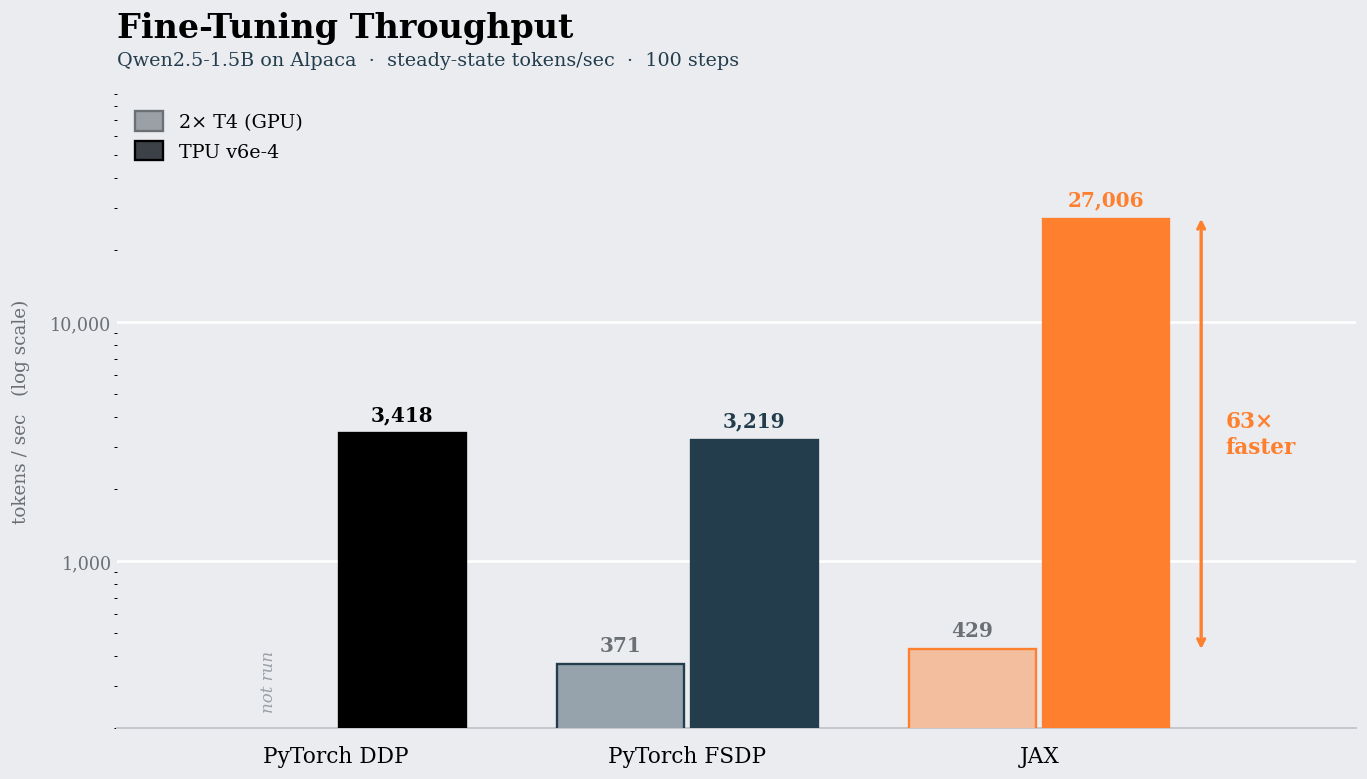

In [68]:
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator, FuncFormatter, NullFormatter
from matplotlib.patches import Patch

def tint(color, amount=0.58, bg=COLORS["bg"]):
    """Blend a color toward the background — used to mark the weaker hardware."""
    c, b = np.array(mcolors.to_rgb(color)), np.array(mcolors.to_rgb(bg))
    return tuple(c + (b - c) * amount)

FRAMEWORKS = ["PyTorch DDP", "PyTorch FSDP", "JAX"]
HARDWARES  = ["T4_x2", "TPU_4_cores"]
HW_LABEL   = {"T4_x2": "2× T4 (GPU)", "TPU_4_cores": "TPU v6e-4"}

def val(hw, fw, col="mean_tok_s"):
    r = summary[(summary.hardware == hw) & (summary.framework == fw)]
    return float(r[col].iloc[0]) if len(r) else np.nan

fig, ax = plt.subplots(figsize=(11.5, 6.6))

x, width = np.arange(len(FRAMEWORKS)), 0.36

for i, hw in enumerate(HARDWARES):
    solid = hw == "TPU_4_cores"
    vals  = [val(hw, fw) for fw in FRAMEWORKS]
    pos   = x + (i - 0.5) * (width + 0.02)
    face  = [FRAMEWORK_COLORS[f] if solid else tint(FRAMEWORK_COLORS[f]) for f in FRAMEWORKS]

    ax.bar(pos, vals, width, color=face, zorder=3,
           edgecolor=[FRAMEWORK_COLORS[f] for f in FRAMEWORKS], linewidth=1.4)

    for p, v, f in zip(pos, vals, FRAMEWORKS):
        if np.isnan(v):
            ax.text(p, 235, "not run", ha="center", va="bottom", rotation=90,
                    fontsize=10, style="italic", color="#9AA0A6")
        else:
            ax.text(p, v * 1.09, f"{v:,.0f}", ha="center", va="bottom",
                    fontsize=12, fontweight="bold",
                    color=FRAMEWORK_COLORS[f] if solid else "#6B7075")

# speedup bracket on the JAX pair
lo, hi = val("T4_x2", "JAX"), val("TPU_4_cores", "JAX")
bx = x[-1] + 0.46
ax.annotate("", xy=(bx, hi), xytext=(bx, lo),
            arrowprops=dict(arrowstyle="<->", color=COLORS["orange"], lw=2.0,
                            shrinkA=0, shrinkB=0))
ax.text(bx + 0.07, np.sqrt(lo * hi), f"{hi/lo:.0f}×\nfaster",
        ha="left", va="center", fontsize=13, fontweight="bold",
        color=COLORS["orange"], linespacing=1.25)

ax.set_yscale("log")
ax.set_ylim(200, 90_000)
ax.set_xlim(-0.62, len(FRAMEWORKS) - 0.10)
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:,.0f}"))
ax.yaxis.set_minor_formatter(NullFormatter())

ax.set_xticks(x)
ax.set_xticklabels(FRAMEWORKS, fontsize=13)
ax.tick_params(axis="x", length=0, pad=10)
ax.tick_params(axis="y", labelsize=10.5, colors="#6B7075", length=0)
ax.set_ylabel("tokens / sec   (log scale)", fontsize=11, color="#6B7075", labelpad=12)

ax.grid(False)
ax.yaxis.grid(True, color="#FFFFFF", linewidth=1.6, zorder=0)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#C3C8CE")
ax.spines["bottom"].set_linewidth(1.2)

ax.set_title("Fine-Tuning Throughput", fontsize=20, fontweight="bold",
             loc="left", pad=34, color=COLORS["black"])
ax.text(0, 1.045, "Qwen2.5-1.5B on Alpaca  ·  steady-state tokens/sec  ·  100 steps",
        transform=ax.transAxes, fontsize=11.5, color=COLORS["navy"])

ax.legend(handles=[
    Patch(facecolor="#9AA0A6", edgecolor="#6B7075", lw=1.4, label=HW_LABEL["T4_x2"]),
    Patch(facecolor="#3C4147", edgecolor=COLORS["black"], lw=1.4, label=HW_LABEL["TPU_4_cores"]),
], frameon=False, fontsize=11.5, loc="upper left", handlelength=1.5, handleheight=1.2)

fig.tight_layout()
fig.savefig("throughput.png", dpi=230, facecolor=COLORS["bg"], bbox_inches="tight")
plt.show()

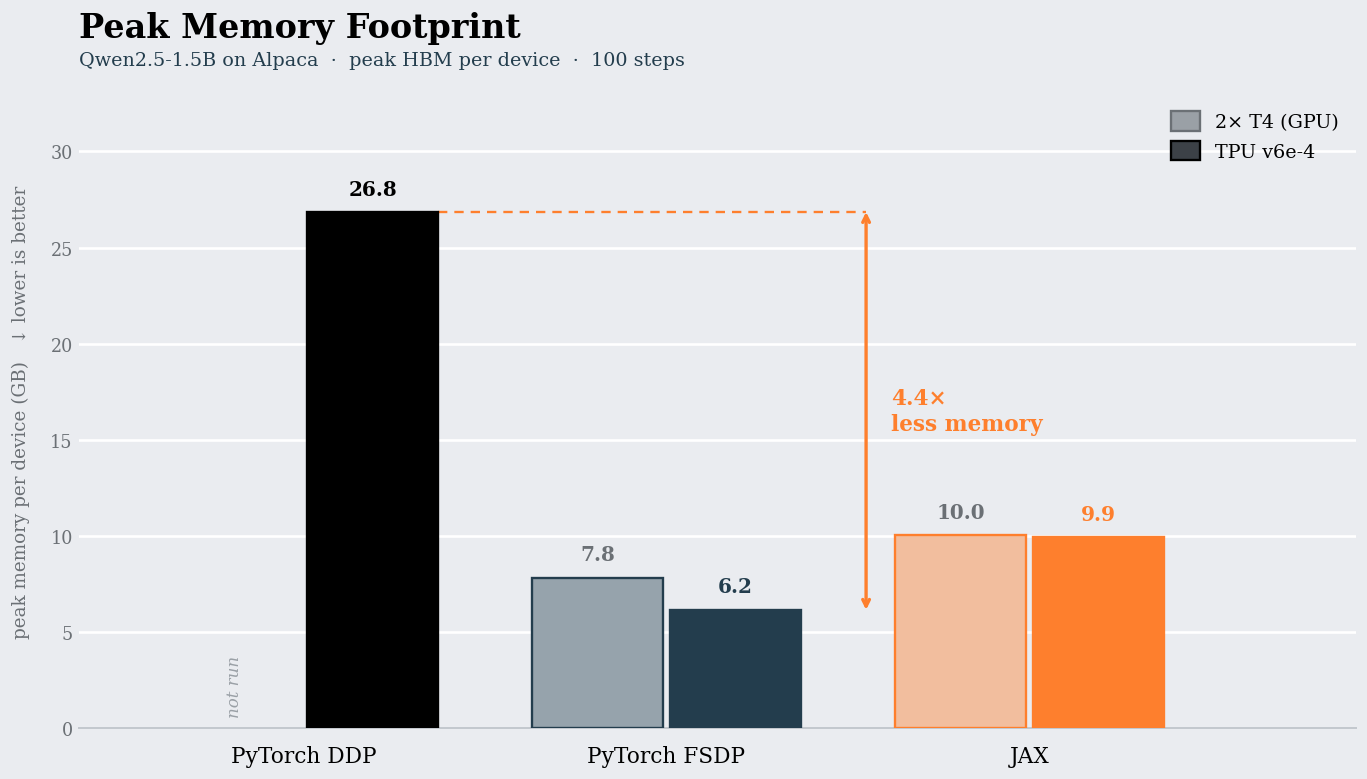

In [70]:
fig, ax = plt.subplots(figsize=(11.5, 6.6))

x, width = np.arange(len(FRAMEWORKS)), 0.36
MB_TO_GB = 1 / 1024

for i, hw in enumerate(HARDWARES):
    solid = hw == "TPU_4_cores"
    vals  = [val(hw, fw, "peak_mem_mb") * MB_TO_GB for fw in FRAMEWORKS]
    pos   = x + (i - 0.5) * (width + 0.02)
    face  = [FRAMEWORK_COLORS[f] if solid else tint(FRAMEWORK_COLORS[f]) for f in FRAMEWORKS]

    ax.bar(pos, vals, width, color=face, zorder=3,
           edgecolor=[FRAMEWORK_COLORS[f] for f in FRAMEWORKS], linewidth=1.4)

    for p, v, f in zip(pos, vals, FRAMEWORKS):
        if np.isnan(v):
            ax.text(p, 0.6, "not run", ha="center", va="bottom", rotation=90,
                    fontsize=10, style="italic", color="#9AA0A6")
        else:
            ax.text(p, v + 0.7, f"{v:.1f}", ha="center", va="bottom",
                    fontsize=12, fontweight="bold",
                    color=FRAMEWORK_COLORS[f] if solid else "#6B7075")

# DDP -> FSDP memory saving on TPU (bars sit in different groups, so bridge them)
ddp_gb  = val("TPU_4_cores", "PyTorch DDP",  "peak_mem_mb") * MB_TO_GB
fsdp_gb = val("TPU_4_cores", "PyTorch FSDP", "peak_mem_mb") * MB_TO_GB
bx = 1.55

ax.plot([0.37, bx], [ddp_gb, ddp_gb], ls=(0, (4, 3)), lw=1.4,
        color=COLORS["orange"], zorder=2)
ax.annotate("", xy=(bx, ddp_gb), xytext=(bx, fsdp_gb),
            arrowprops=dict(arrowstyle="<->", color=COLORS["orange"], lw=2.0,
                            shrinkA=0, shrinkB=0))
ax.text(bx + 0.07, (ddp_gb + fsdp_gb) / 2, f"{ddp_gb/fsdp_gb:.1f}×\nless memory",
        ha="left", va="center", fontsize=13, fontweight="bold",
        color=COLORS["orange"], linespacing=1.25)

ax.set_ylim(0, 33)
ax.set_xlim(-0.62, len(FRAMEWORKS) - 0.10)
ax.set_xticks(x)
ax.set_xticklabels(FRAMEWORKS, fontsize=13)
ax.tick_params(axis="x", length=0, pad=10)
ax.tick_params(axis="y", labelsize=10.5, colors="#6B7075", length=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:.0f}"))
ax.set_ylabel("peak memory per device (GB)   ↓ lower is better",
              fontsize=11, color="#6B7075", labelpad=12)

ax.grid(False)
ax.yaxis.grid(True, color="#FFFFFF", linewidth=1.6, zorder=0)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#C3C8CE")
ax.spines["bottom"].set_linewidth(1.2)

ax.set_title("Peak Memory Footprint", fontsize=20, fontweight="bold",
             loc="left", pad=34, color=COLORS["black"])
ax.text(0, 1.045, "Qwen2.5-1.5B on Alpaca  ·  peak HBM per device  ·  100 steps",
        transform=ax.transAxes, fontsize=11.5, color=COLORS["navy"])

ax.legend(handles=[
    Patch(facecolor="#9AA0A6", edgecolor="#6B7075", lw=1.4, label=HW_LABEL["T4_x2"]),
    Patch(facecolor="#3C4147", edgecolor=COLORS["black"], lw=1.4, label=HW_LABEL["TPU_4_cores"]),
], frameon=False, fontsize=11.5, loc="upper right", handlelength=1.5, handleheight=1.2)

fig.tight_layout()
fig.savefig("memory.png", dpi=230, facecolor=COLORS["bg"], bbox_inches="tight")
plt.show()

/tmp/ipykernel_952/3438813127.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.035, 1, 0.965])


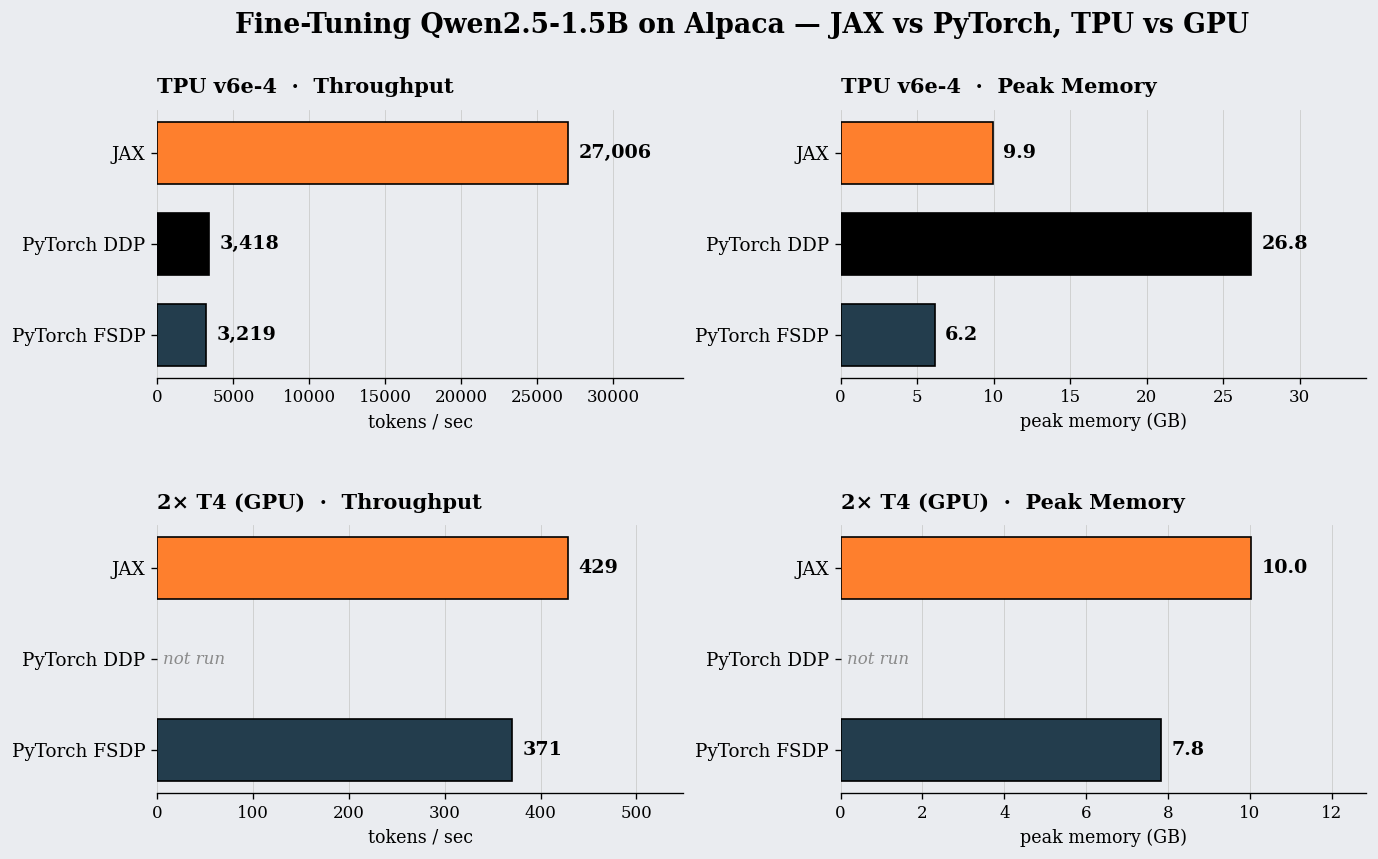

In [65]:
from matplotlib.patches import Patch

FW_ORDER = ["JAX", "PyTorch DDP", "PyTorch FSDP"]
HW_ORDER = ["TPU_4_cores", "T4_x2"]
HW_LABEL = {"TPU_4_cores": "TPU v6e-4", "T4_x2": "2× T4 (GPU)"}

def val(hw, fw, col):
    r = summary[(summary.hardware == hw) & (summary.framework == fw)]
    return float(r[col].iloc[0]) if len(r) else np.nan

PANELS = [("mean_tok_s", "tokens / sec", "{:,.0f}", 1.0),
          ("peak_mem_mb", "peak memory (GB)", "{:.1f}", 1/1024)]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.4),
                         gridspec_kw={"hspace": 0.55, "wspace": 0.30})

for r, hw in enumerate(HW_ORDER):
    for c, (col, xlabel, fmt, scale) in enumerate(PANELS):
        ax = axes[r, c]
        vals = [val(hw, fw, col) * scale for fw in FW_ORDER]
        y = np.arange(len(FW_ORDER))

        ax.barh(y, vals, height=0.68,
                color=[FRAMEWORK_COLORS[fw] for fw in FW_ORDER],
                edgecolor=COLORS["black"], linewidth=1.0, zorder=3)

        finite = [v for v in vals if not np.isnan(v)]
        xmax = max(finite) if finite else 1
        ax.set_xlim(0, xmax * 1.28)

        for yy, v in zip(y, vals):
            if np.isnan(v):
                ax.text(xmax * 0.015, yy, "not run", va="center", ha="left",
                        fontsize=10, style="italic", color="#8A8A8A")
            else:
                ax.text(v + xmax * 0.025, yy, fmt.format(v), va="center", ha="left",
                        fontsize=11.5, fontweight="bold", color=COLORS["black"])

        ax.set_yticks(y); ax.set_yticklabels(FW_ORDER, fontsize=11)
        ax.invert_yaxis()
        ax.set_xlabel(xlabel, fontsize=10.5)
        ax.set_title(f"{HW_LABEL[hw]}  ·  {'Throughput' if c == 0 else 'Peak Memory'}",
                     fontsize=12.5, fontweight="bold", loc="left", pad=10)
        ax.grid(False); ax.xaxis.grid(True, zorder=0)
        for s in ("top", "right", "left"):
            ax.spines[s].set_visible(False)

fig.suptitle("Fine-Tuning Qwen2.5-1.5B on Alpaca — JAX vs PyTorch, TPU vs GPU",
             fontsize=16, fontweight="bold", y=0.99)

sp_hw  = val("TPU_4_cores", "JAX", "mean_tok_s") / val("T4_x2", "JAX", "mean_tok_s")
sp_fw  = val("TPU_4_cores", "JAX", "mean_tok_s") / val("TPU_4_cores", "PyTorch DDP", "mean_tok_s")
sp_mem = val("TPU_4_cores", "PyTorch DDP", "peak_mem_mb") / val("TPU_4_cores", "PyTorch FSDP", "peak_mem_mb")



fig.tight_layout(rect=[0, 0.035, 1, 0.965])
fig.savefig("benchmark_hero.png", dpi=220, facecolor=COLORS["bg"], bbox_inches="tight")
plt.show()

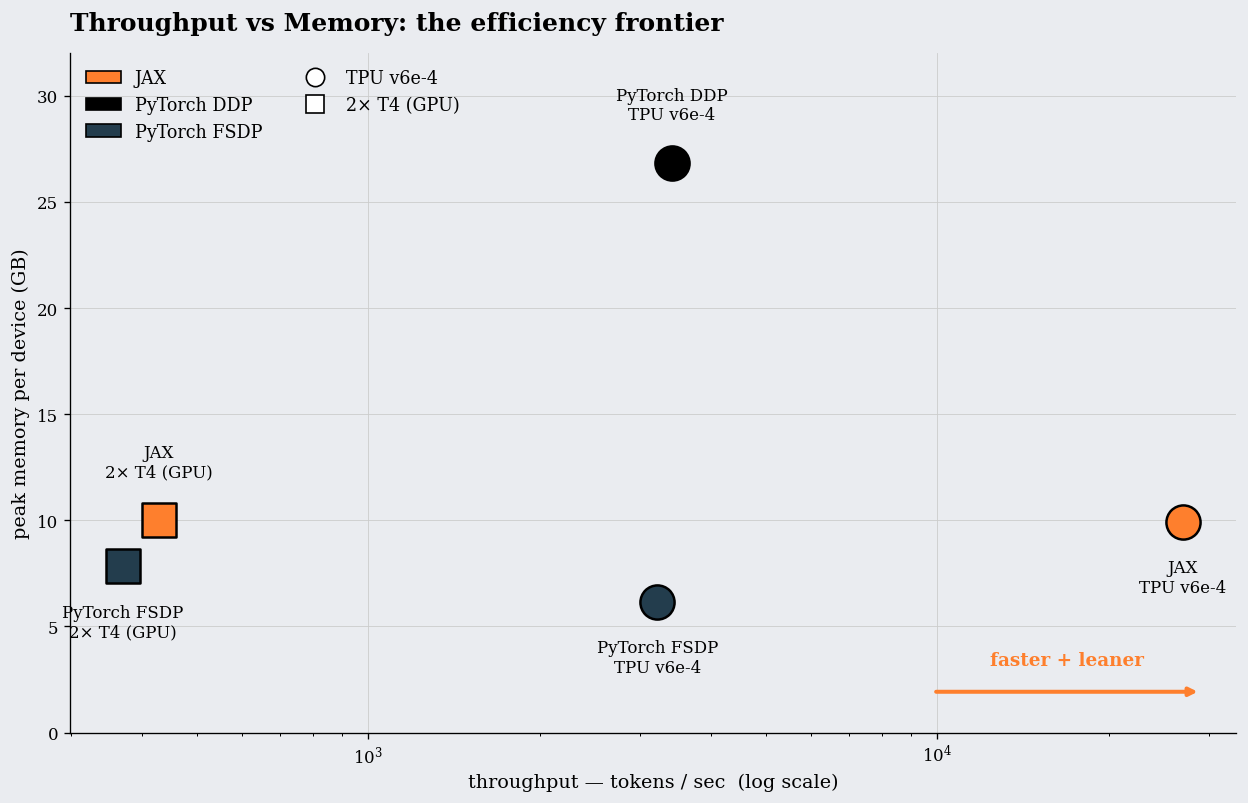

In [66]:
fig, ax = plt.subplots(figsize=(10.5, 6.8))
MARK = {"TPU_4_cores": "o", "T4_x2": "s"}
OFFSETS = {("TPU_4_cores","JAX"): (0,-42), ("TPU_4_cores","PyTorch DDP"): (0,26),
           ("TPU_4_cores","PyTorch FSDP"): (0,-42), ("T4_x2","JAX"): (0,26),
           ("T4_x2","PyTorch FSDP"): (0,-42)}

for hw in HW_ORDER:
    for fw in FW_ORDER:
        x, y = val(hw, fw, "mean_tok_s"), val(hw, fw, "peak_mem_mb") / 1024
        if np.isnan(x):
            continue
        ax.scatter(x, y, s=420, marker=MARK[hw], color=FRAMEWORK_COLORS[fw],
                   edgecolor=COLORS["black"], linewidth=1.5, zorder=3)
        ax.annotate(f"{fw}\n{HW_LABEL[hw]}", (x, y), textcoords="offset points",
                    xytext=OFFSETS.get((hw, fw), (0, 26)), ha="center",
                    fontsize=10, color=COLORS["black"], zorder=4)

ax.set_xscale("log")
ax.set_xlabel("throughput — tokens / sec  (log scale)", fontsize=11.5)
ax.set_ylabel("peak memory per device (GB)", fontsize=11.5)
ax.set_title("Throughput vs Memory: the efficiency frontier",
             fontsize=15, fontweight="bold", loc="left", pad=14)
ax.set_ylim(0, 32)

ax.annotate("", xy=(0.97, 0.06), xytext=(0.74, 0.06), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color=COLORS["orange"], lw=2.4))
ax.text(0.855, 0.10, "faster + leaner", transform=ax.transAxes, ha="center",
        fontsize=11, fontweight="bold", color=COLORS["orange"])

ax.legend(handles=[Patch(facecolor=FRAMEWORK_COLORS[f], edgecolor=COLORS["black"], label=f)
                   for f in FW_ORDER] +
                  [plt.Line2D([], [], marker="o", ls="", mfc="white", mec=COLORS["black"],
                              ms=11, label="TPU v6e-4"),
                   plt.Line2D([], [], marker="s", ls="", mfc="white", mec=COLORS["black"],
                              ms=11, label="2× T4 (GPU)")],
          frameon=False, loc="upper left", fontsize=10.5, ncol=2)

for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("benchmark_frontier.png", dpi=220, facecolor=COLORS["bg"], bbox_inches="tight")
plt.show()

/tmp/ipykernel_952/1808685419.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


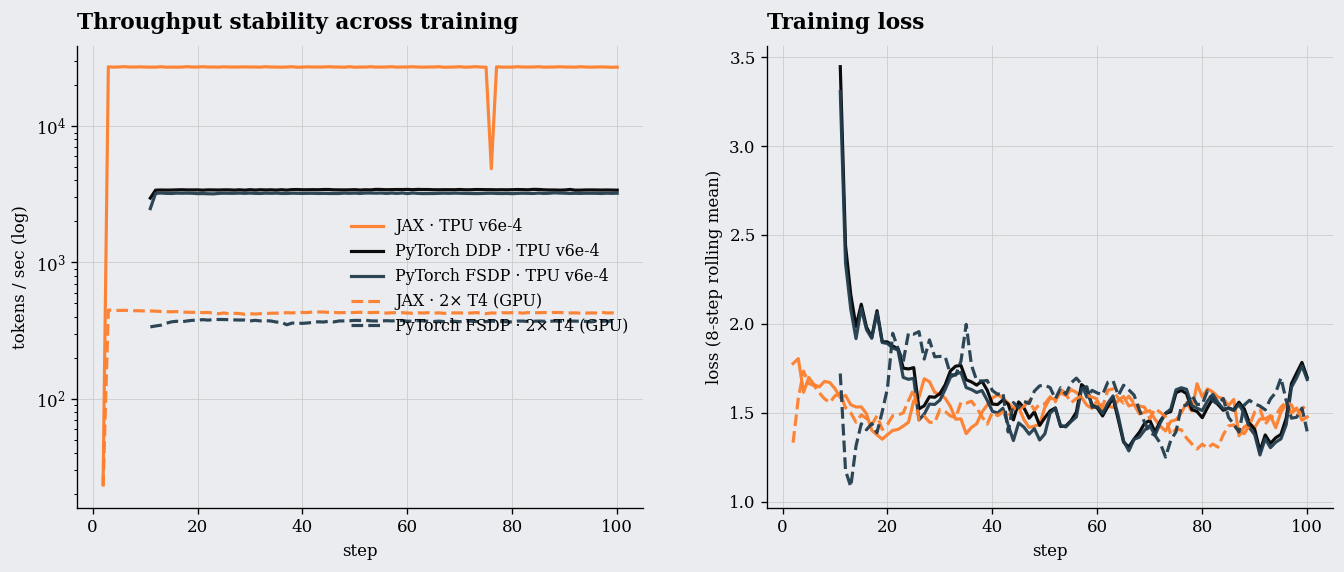

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), gridspec_kw={"wspace": 0.22})

for hw in HW_ORDER:
    for fw in FW_ORDER:
        g = df[(df.hardware == hw) & (df.framework == fw)]
        if g.empty:
            continue
        ls = "-" if hw == "TPU_4_cores" else "--"
        axes[0].plot(g["step"], g["tokens_per_sec"], ls=ls, lw=1.9,
                     color=FRAMEWORK_COLORS[fw], alpha=0.95,
                     label=f"{fw} · {HW_LABEL[hw]}")
        axes[1].plot(g["step"], g["loss"].rolling(8, min_periods=1).mean(), ls=ls, lw=1.9,
                     color=FRAMEWORK_COLORS[fw], alpha=0.95)

axes[0].set_yscale("log")
axes[0].set_xlabel("step"); axes[0].set_ylabel("tokens / sec (log)")
axes[0].set_title("Throughput stability across training",
                  fontsize=13, fontweight="bold", loc="left", pad=10)
axes[0].legend(frameon=False, fontsize=9.5, loc="center right")

axes[1].set_xlabel("step"); axes[1].set_ylabel("loss (8-step rolling mean)")
axes[1].set_title("Training loss", fontsize=13, fontweight="bold", loc="left", pad=10)

for ax in axes:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("benchmark_curves.png", dpi=220, facecolor=COLORS["bg"], bbox_inches="tight")
plt.show()